# Repository Prediction Pipeline Demo

This notebook is designed for a repo reviewer or collaborator who wants to see the inference pipeline in action.
It uses one of the repository's existing trained models to make predictions on a real experimental chain, and it verifies the synthetic-data preprocessing used during model training.


## Setup and imports

The first step configures the repository path and imports the utilities required for data loading, preprocessing, and inference.
We import both the training-side helpers and the experimental prediction helpers so the notebook matches the repository workflow.


In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path(".").resolve()
sys.path.append(str(ROOT / "src"))

from train_ensemble import compute_didv_from_flat, make_windows, split_data_grouped
from predict_experimental_chains import (
    cut_and_resample_map_to_200,
    load_symmetric_experiment_chain,
    preprocess_experiment_chain,
    predict_chain_J,
)
import keras

print("ROOT =", ROOT)
print("keras version =", keras.__version__)


ROOT = /u/06/lupig1/data/Desktop/Inhomogeneous-Heisenberg-HL
keras version = 3.11.3


## Load a trained model

This section selects an existing trained model from `models/trained_models` and loads it with Keras.
The saved model is the same format produced by `src/train_ensemble.py`, so this shows how inference can be reproduced directly from repository artifacts.


In [ ]:
model_base = ROOT / "models" / "trained_models"
available = sorted([p.name for p in model_base.glob("enhanced_seed_*")])
print("available enhanced model directories:\n", available[:12])

selected_seed = "enhanced_seed_43"
model_path = model_base / selected_seed / "model.keras"
print("selected model path:\n", model_path)
model = keras.saving.load_model(model_path)
print("loaded model successfully")


## Load experimental STM data

Here we load a symmetrized experimental chain from `data/experimental`.
The data is expected in the CSV format used by the repository, with columns `bias_meV`, `site`, and `didv_A`.
We also plot the raw site-resolved spectra to show the input to the pipeline.


experimental CSV found: True
didv_sym shape: (6, 200)


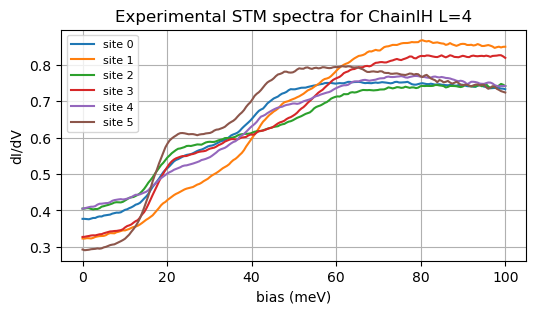

In [14]:
chain_name = "ChainIH"
L = 6
bias_train = np.linspace(0.0, 100.0, 200, dtype=np.float32)
csv_path = ROOT / "data" / "experimental" / f"{chain_name}_L{L}_SYM.csv"
print("experimental CSV found:", csv_path.exists())
didv_sym = load_symmetric_experiment_chain(
    chain_name=chain_name,
    L=L,
    bias_train=bias_train,
    data_dir=ROOT / "data" / "experimental",
)
print("didv_sym shape:", didv_sym.shape)

plt.figure(figsize=(6, 3))
for site in range(L):
    plt.plot(bias_train, didv_sym[site], label=f"site {site}")
plt.xlabel("bias (meV)")
plt.ylabel("dI/dV")
plt.title("Experimental STM spectra for ChainIH L=4")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


## Preprocess experimental spectra

The model expects spectra with a fixed bias window and normalized baselines.
This section performs the same resampling and baseline scaling used in training, so the input exactly matches the network's expected format.


normalized input shape: (1, 1200)


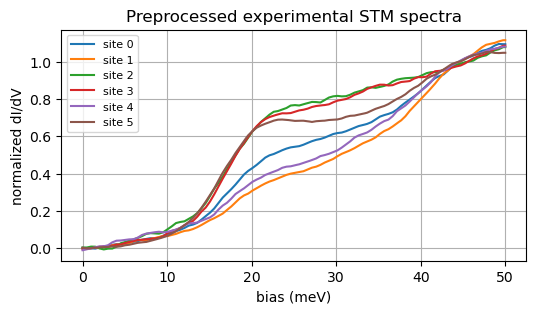

In [15]:
res = 200
didv_cut = cut_and_resample_map_to_200(didv_sym, bias_train, cut_mev=50.0, n_out=res)
didv_norm = preprocess_experiment_chain(
    didv_cut.reshape(1, L * res),
    L=L,
    res=res,
    full_mev=50.0,
    cut_mev=50.0,
    baseline_mev=3,
    scale_band_mev=(40, 50),
    clip=None,
)
print("normalized input shape:", didv_norm.shape)

plt.figure(figsize=(6, 3))
for site in range(L):
    plt.plot(np.linspace(0, 50, res), didv_norm[0, site * res:(site + 1) * res], label=f"site {site}")
plt.xlabel("bias (meV)")
plt.ylabel("normalized dI/dV")
plt.title("Preprocessed experimental STM spectra")
plt.legend(fontsize=8)
plt.grid(True)
plt.show()


## Predict local exchange couplings

The trained model is applied to the preprocessed chain using a sliding-window approach.
The output is a prediction for the nearest-neighbor couplings `J_n` along the chain, which the model learned as normalized values in [0, 1].
We then unscale the predictions back to the original physical range of 30–45 meV.

predicted J_n (scaled [0,1]): [0.47021627 0.24549219 0.3863762  0.27014345 0.42881694]
predicted J_n (unscaled meV): [37.053246 33.682384 35.795643 34.05215  36.432255]


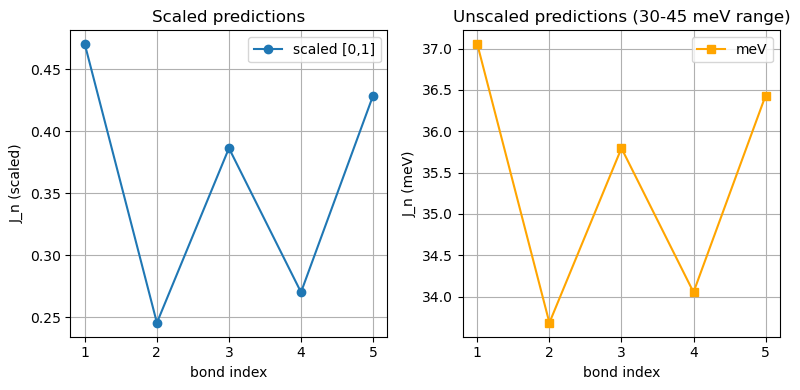

In [16]:
if 'model' not in locals():
    model_base = ROOT / "models" / "trained_models"
    selected_seed = "enhanced_seed_43"
    model_path = model_base / selected_seed / "model.keras"
    model = keras.saving.load_model(model_path)
    print("loaded model")

J_pred_scaled = predict_chain_J(didv_norm, L=L, res=res, model=model)[0]
print("predicted J_n (scaled [0,1]):", J_pred_scaled)

# Unscale from [0,1] back to original J range (30-45 meV)
J_min = 30.0
J_max = 45.0
J_pred = J_pred_scaled * (J_max - J_min) + J_min
print("predicted J_n (unscaled meV):", J_pred)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, L), J_pred_scaled, marker="o", linestyle="-", label="scaled [0,1]")
plt.xlabel("bond index")
plt.ylabel("J_n (scaled)")
plt.title("Scaled predictions")
plt.xticks(range(1, L))
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, L), J_pred, marker="s", linestyle="-", color="orange", label="meV")
plt.xlabel("bond index")
plt.ylabel("J_n (meV)")
plt.title("Unscaled predictions (30-45 meV range)")
plt.xticks(range(1, L))
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## Synthetic data sanity check

This final section reconnects the inference pipeline with the training pipeline.
It loads synthetic data, computes the same dI/dV representations used to train the model, and assembles sliding-window inputs.
This helps a reviewer understand both sides of the repository workflow: training and inference.


In [10]:
data_path = ROOT / "data" / "synthetic" / "dataset_35_45.npz"
dataset = np.load(data_path)
X_flat = dataset["X"]
Z_flat = dataset["Z"]
J = dataset["J"]

didv = compute_didv_from_flat(Z_flat=Z_flat, X_flat=X_flat, n_sites=12, n_bias=200)
print("synthetic didv shape:", didv.shape)

X_all, y_all = make_windows(didv, J, n=12, res=200)
print("windowed synthetic X shape:", X_all.shape, "y shape:", y_all.shape)

X_train, X_val, X_test, y_train, y_val, y_test = split_data_grouped(
    didv,
    J,
    n=12,
    res=200,
    test_size=0.1,
    val_size=0.2,
    seed=42,
)
print("test set example J labels:", y_test[:3])


synthetic didv shape: (1500, 2400)
windowed synthetic X shape: (15000, 600) y shape: (15000, 2)
test set example J labels: [[4.272699  3.618116 ]
 [3.9432733 3.5465915]
 [3.7472577 3.869348 ]]
